<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH09/CH09_NB01_MoE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Rearchitecting LLMs
## Structural techniques for efficient models

### Chapter 9: Mixture of Experts (MoE)

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: GPU T4

Models:
- HuggingFaceTB/SmolLM2-1.7B-Instruct

_____
This notebook builds a two-expert MoE adaptation on top of SmolLM2 to preserve general behavior while improving clinical extraction.
It trains a router and one domain expert, then compares soft vs hard routing through schema-compliance evaluation and token-level routing analysis.

# Setting up the notebook

This section installs dependencies, imports required modules, and defines utility helpers used across the notebook.

In [1]:
!pip install -q \
    transformers==5.0.0 \
    datasets==4.0.0 \
    accelerate==1.12.0 \
    langdetect \
    codecarbon \
    lm-eval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import copy
import json
import random
import gc
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import autocast, GradScaler
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
random.seed(0)
print("Running on:", DEVICE)



Running on: cuda


In [3]:
if os.path.exists('../utils.py') and not os.path.exists('utils.py'):
    import shutil
    shutil.copy('../utils.py', 'utils.py')
if not os.path.exists('utils.py'):
    import subprocess
    subprocess.run(['wget', '-q',
        'https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py'],
        check=True)

from utils import model_evaluation

In [4]:
def clear_gpu_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

def set_seed(seed=42):
    """Set random seed for reproducibility"""
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("✓ Random seed set to 42")

✓ Random seed set to 42


## Configuration

Centralized parameters for reproducible experiments. Adjust values here to rerun the notebook with different settings.

In [5]:
# Core model and training setup
MODEL_NAME = "HuggingFaceTB/SmolLM2-1.7B-Instruct"
EPOCHS = 3
LAYERS_TO_MODIFY = range(13, 24)  # Last 11 layers of the 24-layer model

# Dataset sizes
CLINICAL_TRAIN_SAMPLES = 300
GENERAL_TRAIN_SAMPLES = 300

# Sequence and generation settings
MAX_TRAIN_LENGTH = 512
MAX_GENERAL_TEST_TOKENS = 50
MAX_CLINICAL_TEST_TOKENS = 150
MAX_EVAL_TOKENS = 400

#Benchmarks configuration
BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa"
]
BENCHMARK_LIMIT = None

# Set to True to run lm-eval benchmarks on each model variant.
# Benchmarks add significant runtime; keep False to skip and only evaluate
# schema compliance.
RUN_FULL_BENCHMARKS = True

# Reproducibility and runtime
SEED = 42
set_seed(SEED)
print(f"Configuration loaded | seed={SEED} | epochs={EPOCHS}")

Configuration loaded | seed=42 | epochs=3


## Base model and dataset

Load the base instruction model and the clinical training split used to build specialization prompts.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)
model.to(DEVICE)
print(f"Base model: {sum(p.numel() for p in model.parameters()):,} parameters")

# Clinical dataset used in Chapter 7
dataset = load_dataset("oopere/clinical-ner-qdora")
train_data = dataset["train"].select(range(CLINICAL_TRAIN_SAMPLES))
print(f"\nClinical dataset loaded: {len(train_data)} training examples")
print(f"Sample note: {train_data[0]['note'][:100]}...")

# General prompts from SmolTalk
smoltalk = load_dataset("HuggingFaceTB/smoltalk", "all", split="train")
smoltalk_single = smoltalk.filter(
    lambda x: len(x["messages"]) == 2 and len(x["messages"][0]["content"]) < 300
)
general_subset = smoltalk_single.select(range(GENERAL_TRAIN_SAMPLES))

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.76k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

Loading base model...


...

data/all/train-00008-of-00009.parquet:   0%|          | 0.00/224M [00:00<?, ?B/s]

data/all/test-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1043917 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/54948 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1043917 [00:00<?, ? examples/s]

In [7]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 2048, padding_idx=2)
    (layers): ModuleList(
      (0-23): 24 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), ep

In [8]:
def run_moe(prompt, max_tokens=100):
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    input_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(outputs[0][input_len:],
                            skip_special_tokens=True).strip()

In [9]:
print("=" * 52)
print("A TEST RESULTS")
print("=" * 52)

# Test A — general knowledge
messages_general = [{"role": "user", "content": "What's the most significant building in Barcelona?"}]
prompt_general   = tokenizer.apply_chat_template(
    messages_general, tokenize=False, add_generation_prompt=True)
print("\n[Test A — General knowledge]")
print(f"Response: {run_moe(prompt_general, max_tokens=400)}")

A TEST RESULTS

[Test A — General knowledge]
Response: The most significant building in Barcelona is the Sagrada Familia, a large-scale Roman Catholic church designed by Antoni Gaudí. It is one of the most famous buildings in the world and a major tourist attraction. The Sagrada Familia is a UNESCO World Heritage Site and is considered a masterpiece of Catalan Modernism.


## MoE block definition

Define a two-expert MoE module with a trainable router. During training it uses soft routing so gradients can update both router and expert parameters.

In [10]:
class Trainable2ExpertMoE(nn.Module):
    """Two-expert soft MoE block.

    Args:
        original_mlp: the MLP from the decoder layer. Becomes Expert 0 (general).
                      Expert 1 (clinical) is initialized as a deep copy of it.
        hidden_size: model hidden dimension, used to size the router.
    """

    def __init__(self, original_mlp, hidden_size):
        super().__init__()
        target_dtype = next(original_mlp.parameters()).dtype
        target_device = next(original_mlp.parameters()).device

        self.expert_general = original_mlp
        self.expert_clinical = copy.deepcopy(original_mlp)
        self.router = nn.Linear(hidden_size, 2, bias=False,
                                dtype=target_dtype, device=target_device)
        self.last_routing = None

    def forward(self, hidden_states):
        router_logits = self.router(hidden_states)

        if self.training:
            noise = torch.randn_like(router_logits) * 0.35
            router_logits = router_logits + noise

        # Upcast to FP32 for softmax numerical stability
        routing_weights = F.softmax(router_logits.float(), dim=-1).to(hidden_states.dtype)

        out_general = self.expert_general(hidden_states)
        out_clinical = self.expert_clinical(hidden_states)

        # Soft routing: each token receives a weighted blend of both experts
        output = out_general * routing_weights[..., 0].unsqueeze(-1) + out_clinical * routing_weights[..., 1].unsqueeze(-1)
        self.last_routing = routing_weights.detach()

        return output

## Layer surgery

Replace selected decoder MLP blocks with the MoE module so only deeper layers are specialized.

In [11]:
hidden_size = model.config.hidden_size

for layer_idx in LAYERS_TO_MODIFY:
    original_mlp = model.model.layers[layer_idx].mlp
    model.model.layers[layer_idx].mlp = Trainable2ExpertMoE(original_mlp, hidden_size)

print(f"Surgery complete: {len(LAYERS_TO_MODIFY)} MLP layers replaced with MoE blocks.")

Surgery complete: 11 MLP layers replaced with MoE blocks.


In [12]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 2048, padding_idx=2)
    (layers): ModuleList(
      (0-12): 13 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
      (13-23): 11 x LlamaDecoderLayer(
   

## Freezing strategy

Freeze the base model and train only the clinical expert and the router in each modified layer.

In [13]:
# Freeze the entire model first
for param in model.parameters():
    param.requires_grad_(False)

# Unfreeze Expert 1 (clinical) and the router in each MoE block
for layer_idx in LAYERS_TO_MODIFY:
    for param in model.model.layers[layer_idx].mlp.expert_clinical.parameters():
        param.requires_grad_(True)
    for param in model.model.layers[layer_idx].mlp.router.parameters():
        param.requires_grad_(True)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters              : {total:,}")
print(f"Trainable (Expert 1 + router) : {trainable:,}  ({trainable/total:.2%})")

Total parameters              : 2,265,069,568
Trainable (Expert 1 + router) : 553,693,184  (24.44%)


## Training data assembly

Create a mixed prompt set: clinical extraction examples plus general SmolTalk prompts, then shuffle for joint training.

In [14]:
# Clinical prompts: exact format used in Chapter 7 fine-tuning
clinical_prompts = []
for item in train_data:
    label = json.loads(item["label"]) if isinstance(item["label"], str) else item["label"]
    messages = [
        {"role": "system", "content": "Extract:"},
        {"role": "user", "content": item["note"]},
        {"role": "assistant", "content": json.dumps(label, indent=2)},
    ]
    clinical_prompts.append(
        tokenizer.apply_chat_template(messages, tokenize=False,
                                      add_generation_prompt=False)
    )

general_prompts = []
for item in general_subset:
    general_prompts.append(
        tokenizer.apply_chat_template(
            item["messages"],
            tokenize=False,
            add_generation_prompt=False,
        )
    )

training_prompts = clinical_prompts + general_prompts
random.shuffle(training_prompts)
print(
    f"Training prompts - clinical: {len(clinical_prompts)} | "
    f"general: {len(general_prompts)} | total: {len(training_prompts)}"
)

Training prompts - clinical: 300 | general: 300 | total: 600


## MoE training function

Define the training routine for router and clinical experts using mixed-precision optimization.

In [15]:
def train_MoE_router_expert(model):
    model.config.use_cache = False
    model.to(DEVICE).train()

    # Promote trainable parameters to FP32 for optimizer stability
    for param in model.parameters():
        if param.requires_grad:
            param.data = param.data.float()

    router_params = []
    expert_params = []

    for layer_idx in LAYERS_TO_MODIFY:
        router_params.extend(model.model.layers[layer_idx].mlp.router.parameters())
        expert_params.extend(model.model.layers[layer_idx].mlp.expert_clinical.parameters())

    optimizer = optim.AdamW([
        {"params": router_params, "lr": 1e-6},
        {"params": expert_params, "lr": 1e-5},
    ])

    scaler = GradScaler("cuda")

    for epoch in range(EPOCHS):
        total_loss = 0
        random.shuffle(training_prompts)

        for idx, text in enumerate(training_prompts):
            inputs = tokenizer(
                text, return_tensors="pt",
                truncation=True, max_length=MAX_TRAIN_LENGTH
            ).to(DEVICE)

            optimizer.zero_grad()

            with autocast("cuda", dtype=torch.float16):
                loss = model(**inputs, labels=inputs["input_ids"]).loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            if (idx + 1) % 100 == 0:
                print(
                    f"  Epoch {epoch+1}  step {idx+1}/{len(training_prompts)}  loss: {loss.item():.4f}"
                )

        print(f"-> END EPOCH {epoch+1:02d}  avg loss: {total_loss/len(training_prompts):.4f}\n")

    model.config.use_cache = True
    print("Router training complete.")

In [16]:
clear_gpu_cache()

## Training execution

Run optimization over the mixed prompt dataset to specialize the clinical expert and train routing behavior.

In [17]:
train_MoE_router_expert(model)

  Epoch 1  step 100/600  loss: 0.4507
  Epoch 1  step 200/600  loss: 0.5885
  Epoch 1  step 300/600  loss: 0.2248
  Epoch 1  step 400/600  loss: 0.5637
  Epoch 1  step 500/600  loss: 0.3816
  Epoch 1  step 600/600  loss: 0.3007
-> END EPOCH 01  avg loss: 0.6741

  Epoch 2  step 100/600  loss: 0.4064
  Epoch 2  step 200/600  loss: 0.2771
  Epoch 2  step 300/600  loss: 0.2726
  Epoch 2  step 400/600  loss: 0.7377
  Epoch 2  step 500/600  loss: 0.8566
  Epoch 2  step 600/600  loss: 0.2199
-> END EPOCH 02  avg loss: 0.4838

  Epoch 3  step 100/600  loss: 0.2179
  Epoch 3  step 200/600  loss: 0.8432
  Epoch 3  step 300/600  loss: 0.7221
  Epoch 3  step 400/600  loss: 0.4699
  Epoch 3  step 500/600  loss: 0.3881
  Epoch 3  step 600/600  loss: 0.4552
-> END EPOCH 03  avg loss: 0.3928

Router training complete.


## A/B generation and routing inspection

Evaluate qualitative behavior on a general prompt and a clinical prompt, then inspect per-token expert routing.

In [18]:
model.to(torch.float16)
model.eval()

# Test A - general knowledge
messages_general = [{"role": "user",
                     "content": "What's the most significant building in Barcelona?"}]
prompt_general = tokenizer.apply_chat_template(
    messages_general, tokenize=False, add_generation_prompt=True
)
print("[Test A - General knowledge]")
print(f"Response: {run_moe(prompt_general, max_tokens=MAX_GENERAL_TEST_TOKENS)}\n")

# Test B - clinical NER
nota_test = (
    "Patient is a 50 yo F c/o severe chest pain and SOB since yesterday. "
    "Vitals: HR 110, BP 150/90. Started on Aspirin 81mg."
)
messages_clinical = [
    {"role": "system", "content": "Extract:"},
    {"role": "user", "content": nota_test},
]
prompt_clinical = tokenizer.apply_chat_template(
    messages_clinical, tokenize=False, add_generation_prompt=True
)
print("[Test B - Clinical NER]")
print(f"Response: {run_moe(prompt_clinical, max_tokens=MAX_CLINICAL_TEST_TOKENS)}")

[Test A - General knowledge]
Response: The most significant building in Barcelona is the Sagrada Familia, a large-scale Roman Catholic church designed by Antoni Gaudí. It is one of the most famous buildings in the world and a major tourist attraction.

[Test B - Clinical NER]
Response: {
  "patient_age": 50,
  "symptoms": [
    "chest pain",
    "shortness of breath"
  ],
  "vital_signs": {
    "temperature": null,
    "heart_rate": 110,
    "blood_pressure": "150/90"
  },
  "medications": [
    {
      "name": "Aspirin",
      "dose": "81mg",
      "frequency": "not specified"
    }
  ],
  "duration_days": 1
}


In [19]:
messages_general

[{'role': 'user',
  'content': "What's the most significant building in Barcelona?"}]

In [20]:
messages_clinical

[{'role': 'system', 'content': 'Extract:'},
 {'role': 'user',
  'content': 'Patient is a 50 yo F c/o severe chest pain and SOB since yesterday. Vitals: HR 110, BP 150/90. Started on Aspirin 81mg.'}]

In [21]:
def analyze_routing(text, layer_index=0):
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        with torch.amp.autocast("cuda", dtype=torch.float16):
            _ = model(**inputs)

    moe_layer      = model.model.layers[layer_index].mlp
    routing_weights = moe_layer.last_routing.squeeze(0)
    tokens          = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    print(f"Routing analysis (layer {layer_index}):")
    print(f"{'Token':<18} | {'Expert 0 (General)':<20} | {'Expert 1 (Clinical)'}")
    print("-" * 65)
    for token, weights in zip(tokens, routing_weights):
        clean = token.replace("Ġ", "").replace(" ", "")
        print(f"{clean:<18} | {weights[0].item():<20.4f} | {weights[1].item():.4f}")

analyze_routing("What's the most significant building in Barcelona?", layer_index=23)


Routing analysis (layer 23):
Token              | Expert 0 (General)   | Expert 1 (Clinical)
-----------------------------------------------------------------
What               | 0.5142               | 0.4858
's                 | 0.5996               | 0.4001
the                | 0.5796               | 0.4207
most               | 0.5566               | 0.4436
significant        | 0.6035               | 0.3962
building           | 0.5898               | 0.4104
in                 | 0.5430               | 0.4570
Barcelona          | 0.6060               | 0.3940
?                  | 0.5244               | 0.4758


In [22]:
analyze_routing("Patient is a 67-year-old male with chronic pain",
                layer_index=23)

Routing analysis (layer 23):
Token              | Expert 0 (General)   | Expert 1 (Clinical)
-----------------------------------------------------------------
Patient            | 0.5171               | 0.4829
is                 | 0.5049               | 0.4949
a                  | 0.5288               | 0.4712
                   | 0.5039               | 0.4961
6                  | 0.5117               | 0.4883
7                  | 0.5264               | 0.4734
-                  | 0.5234               | 0.4766
year               | 0.6006               | 0.3997
-                  | 0.5723               | 0.4275
old                | 0.4646               | 0.5352
male               | 0.4609               | 0.5391
with               | 0.3804               | 0.6196
chronic            | 0.4685               | 0.5312
pain               | 0.5483               | 0.4514


In [23]:
analyze_routing("Patient is a 67-year-old male with chronic back pain",
                layer_index=23)

Routing analysis (layer 23):
Token              | Expert 0 (General)   | Expert 1 (Clinical)
-----------------------------------------------------------------
Patient            | 0.5171               | 0.4829
is                 | 0.5049               | 0.4949
a                  | 0.5288               | 0.4712
                   | 0.5039               | 0.4961
6                  | 0.5117               | 0.4883
7                  | 0.5264               | 0.4734
-                  | 0.5234               | 0.4766
year               | 0.6006               | 0.3997
-                  | 0.5723               | 0.4275
old                | 0.4646               | 0.5352
male               | 0.4609               | 0.5391
with               | 0.3804               | 0.6196
chronic            | 0.4685               | 0.5312
back               | 0.5537               | 0.4460
pain               | 0.5537               | 0.4460


In [24]:
import pandas as pd

REQUIRED_SCHEMA = {
    "patient_age": (int, type(None)),
    "symptoms": list,
    "vital_signs": dict,
    "medications": list,
    "duration_days": (int, type(None)),
}
VITAL_SIGNS_KEYS = {"temperature", "heart_rate", "blood_pressure"}

def check_schema_compliance(response_text: str) -> dict:
    cleaned = response_text.strip().removeprefix("```json").removesuffix("```").strip()
    try:
        parsed = json.loads(cleaned)
    except json.JSONDecodeError as e:
        return {
            "is_valid_json": False,
            "matches_schema": False,
            "failure_reason": f"JSON parse error: {e}",
        }

    for key, expected_type in REQUIRED_SCHEMA.items():
        if key not in parsed:
            return {
                "is_valid_json": True,
                "matches_schema": False,
                "failure_reason": f"Missing key: '{key}'",
            }
        if not isinstance(parsed[key], expected_type):
            return {
                "is_valid_json": True,
                "matches_schema": False,
                "failure_reason": f"Wrong type for '{key}'",
            }

    for vk in VITAL_SIGNS_KEYS:
        if vk not in parsed.get("vital_signs", {}):
            return {
                "is_valid_json": True,
                "matches_schema": False,
                "failure_reason": f"Missing vital_signs key: '{vk}'",
            }

    return {"is_valid_json": True, "matches_schema": True,
            "failure_reason": None}

def evaluate_moe(label="MoE_Soft"):
    model.eval()
    results = []
    test_dataset = dataset["test"]

    for sample in test_dataset:
        messages = [
            {"role": "system", "content": "Extract:"},
            {"role": "user", "content": sample["note"]},
        ]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        response = run_moe(prompt, max_tokens=MAX_EVAL_TOKENS)
        compliance = check_schema_compliance(response)

        results.append(
            {
                "category": sample["category"],
                "model": label,
                "is_valid_json": compliance["is_valid_json"],
                "matches_schema": compliance["matches_schema"],
                "failure_reason": compliance["failure_reason"],
            }
        )

    return pd.DataFrame(results)

def summarize(df):
    summary = df.groupby("category").agg(
        samples=("is_valid_json", "count"),
        valid_json=("is_valid_json", "sum"),
        schema_ok=("matches_schema", "sum"),
    )
    summary["valid_json_pct"] = (summary["valid_json"] / summary["samples"] * 100).round(1)
    summary["schema_ok_pct"] = (summary["schema_ok"] / summary["samples"] * 100).round(1)
    return summary

print("Evaluating - soft inference...")
soft_results = evaluate_moe(label="MoE_Soft")
print(summarize(soft_results)[["samples", "valid_json_pct", "schema_ok_pct"]].to_string())
print(f"\nOverall schema compliance (soft): {soft_results['matches_schema'].mean()*100:.1f}%")

Evaluating - soft inference...
               samples  valid_json_pct  schema_ok_pct
category                                             
abbreviations        6           100.0          100.0
clean                8           100.0          100.0
implicit             7           100.0          100.0
irrelevant          12           100.0           91.7
typos                7           100.0          100.0

Overall schema compliance (soft): 97.5%


### Failure-case inspection

After aggregate scores, we inspect failing samples in the irrelevant category to understand concrete schema mismatch patterns.

In [25]:
# Inspect failing cases in the irrelevant category
test_dataset = load_dataset("oopere/clinical-ner-qdora", split="test")
irrelevant_samples = [s for s in test_dataset if s["category"] == "irrelevant"]

print(f"Irrelevant samples: {len(irrelevant_samples)}\n")
print("=" * 70)

for i, sample in enumerate(irrelevant_samples):
    messages = [
        {"role": "system", "content": "Extract:"},
        {"role": "user",   "content": sample['note']}
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    response = run_moe(prompt, max_tokens=400)
    compliance = check_schema_compliance(response)

    # Only print failing cases
    if not compliance["matches_schema"]:
        print(f"\n--- FAILING CASE {i+1} ---")
        print(f"NOTE:\n{sample['note']}")
        print(f"\nRESPONSE:\n{response}")
        print(f"\nFAILURE REASON: {compliance['failure_reason']}")
        print("=" * 70)

Irrelevant samples: 12


--- FAILING CASE 9 ---
NOTE:
Patient is a 67-year-old retired teacher who was referred from Dr. Johnson's office last Tuesday. Insurance pre-authorization was approved for this visit (claim #TX-4429). She mentions her daughter drove her here today because of parking concerns downtown. Chief complaint: 'I've been having these dizzy spells for about 2 weeks now, especially when I stand up.' Patient reports episodes of lightheadedness occurring 3-4 times daily. She also notes some fatigue but attributes this to 'getting older.' Vital signs obtained by MA Sarah: BP 90/60, appears lower than her usual readings per patient. Temperature and pulse not documented due to equipment malfunction in room 3. Social history notable for recent loss of spouse 6 months ago, living alone now. Current medications include lisinopril 10mg daily and metformin 500mg twice daily, though patient admits to occasional missed doses due to 'forgetting.' She's scheduled for follow-up labs nex

## Hard routing adaptation (inference only)

Swap the MoE forward behavior to hard token-to-expert decisions at inference time, preserving already-trained weights.

In [26]:
# The weights stay exactly the same. Only inference behavior changes.
class Trainable2ExpertMoE(nn.Module):
    def __init__(self, original_mlp, hidden_size):
        super().__init__()
        target_dtype = next(original_mlp.parameters()).dtype
        target_device = next(original_mlp.parameters()).device
        self.expert_general = original_mlp
        self.expert_clinical = copy.deepcopy(original_mlp)
        self.router = nn.Linear(hidden_size, 2, bias=False,
                                dtype=target_dtype, device=target_device)
        self.last_routing = None

    def forward(self, hidden_states):
        router_logits = self.router(hidden_states)
        routing_weights = F.softmax(router_logits.float(), dim=-1).to(hidden_states.dtype)

        if self.training:
            # Soft routing - gradients flow through the weighted sum
            out_general = self.expert_general(hidden_states)
            out_clinical = self.expert_clinical(hidden_states)
            output = out_general * routing_weights[..., 0].unsqueeze(-1) + out_clinical * routing_weights[..., 1].unsqueeze(-1)
            self.last_routing = routing_weights.detach()
        else:
            # True Hard routing - sparse computation
            expert_choice = torch.argmax(router_logits, dim=-1)

            # Initialize output tensor
            output = torch.zeros_like(hidden_states)

            # Create virtual mask
            mask_general = (expert_choice == 0)
            mask_clinical = (expert_choice == 1)

            # Ejecute only expert selected
            if mask_general.any():
                output[mask_general] = self.expert_general(hidden_states[mask_general])
            if mask_clinical.any():
                output[mask_clinical] = self.expert_clinical(hidden_states[mask_clinical])

            hard_decisions = F.one_hot(expert_choice, num_classes=2).float()
            self.last_routing = hard_decisions.detach()

        return output

# Patch existing MoE layers with the new forward method while preserving weights
for layer_idx in LAYERS_TO_MODIFY:
    old_block = model.model.layers[layer_idx].mlp
    new_block = Trainable2ExpertMoE(old_block.expert_general, hidden_size)
    new_block.expert_clinical.load_state_dict(old_block.expert_clinical.state_dict())
    new_block.router.load_state_dict(old_block.router.state_dict())
    model.model.layers[layer_idx].mlp = new_block

print("Forward method updated. Weights unchanged.")
model.eval()

Forward method updated. Weights unchanged.


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 2048, padding_idx=2)
    (layers): ModuleList(
      (0-12): 13 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
      (13-23): 11 x LlamaDecoderLayer(
   

In [27]:
analyze_routing("What's the most significant building in Barcelona?",
                layer_index=23)


Routing analysis (layer 23):
Token              | Expert 0 (General)   | Expert 1 (Clinical)
-----------------------------------------------------------------
What               | 1.0000               | 0.0000
's                 | 1.0000               | 0.0000
the                | 1.0000               | 0.0000
most               | 1.0000               | 0.0000
significant        | 1.0000               | 0.0000
building           | 1.0000               | 0.0000
in                 | 1.0000               | 0.0000
Barcelona          | 1.0000               | 0.0000
?                  | 1.0000               | 0.0000


In [28]:
analyze_routing("Patient is a 67-year-old male with chronic pain",
                layer_index=23)

Routing analysis (layer 23):
Token              | Expert 0 (General)   | Expert 1 (Clinical)
-----------------------------------------------------------------
Patient            | 1.0000               | 0.0000
is                 | 0.0000               | 1.0000
a                  | 1.0000               | 0.0000
                   | 0.0000               | 1.0000
6                  | 0.0000               | 1.0000
7                  | 1.0000               | 0.0000
-                  | 1.0000               | 0.0000
year               | 1.0000               | 0.0000
-                  | 1.0000               | 0.0000
old                | 0.0000               | 1.0000
male               | 0.0000               | 1.0000
with               | 0.0000               | 1.0000
chronic            | 0.0000               | 1.0000
pain               | 1.0000               | 0.0000


In [36]:
analyze_routing("Patient is a 67-year-old male with chronic back pain",
                layer_index=23)

Routing analysis (layer 23):
Token              | Expert 0 (General)   | Expert 1 (Clinical)
-----------------------------------------------------------------
Patient            | 1.0000               | 0.0000
is                 | 0.0000               | 1.0000
a                  | 1.0000               | 0.0000
                   | 0.0000               | 1.0000
6                  | 0.0000               | 1.0000
7                  | 1.0000               | 0.0000
-                  | 1.0000               | 0.0000
year               | 1.0000               | 0.0000
-                  | 1.0000               | 0.0000
old                | 0.0000               | 1.0000
male               | 0.0000               | 1.0000
with               | 0.0000               | 1.0000
chronic            | 0.0000               | 1.0000
back               | 1.0000               | 0.0000
pain               | 0.0000               | 1.0000


In [29]:
model.to(torch.float16)
model.eval()  # self.training = False -> hard routing

print("Evaluating - hard inference...")
hard_results = evaluate_moe(label="MoE_Hard")
print(summarize(hard_results)[["samples", "valid_json_pct", "schema_ok_pct"]].to_string())
print(f"\nOverall schema compliance (hard): {hard_results['matches_schema'].mean()*100:.1f}%")

# Side-by-side comparison
print("\n--- Soft vs Hard routing ---")
print(f"Soft: {soft_results['matches_schema'].mean()*100:.1f}%")
print(f"Hard: {hard_results['matches_schema'].mean()*100:.1f}%")

Evaluating - hard inference...
               samples  valid_json_pct  schema_ok_pct
category                                             
abbreviations        6           100.0          100.0
clean                8           100.0          100.0
implicit             7           100.0          100.0
irrelevant          12           100.0           91.7
typos                7           100.0          100.0

Overall schema compliance (hard): 97.5%

--- Soft vs Hard routing ---
Soft: 97.5%
Hard: 97.5%


In [30]:
print("=" * 52)
print("  A TEST RESULTS")
print("=" * 52)

# Test A — general knowledge
messages_general = [{"role": "user",
                     "content": "What's the most significant building in Barcelona?"}]
prompt_general   = tokenizer.apply_chat_template(
    messages_general, tokenize=False, add_generation_prompt=True)
print("\n[Test A — General knowledge]")
print(f"Response: {run_moe(prompt_general, max_tokens=400)}")

  A TEST RESULTS

[Test A — General knowledge]
Response: The most significant building in Barcelona is the Sagrada Familia, a large-scale Roman Catholic church designed by Antoni Gaudí.


# Summary and conclusions

This notebook demonstrates how a lightweight two-expert MoE adaptation can preserve general behavior while specializing for clinical extraction.
The soft and hard routing evaluations provide a practical comparison of quality, schema compliance, and routing interpretability.

## Benchmark Evaluation — Baseline vs MoE Soft vs MoE Hard

We run the same five general-knowledge benchmarks used in Chapter 7 to measure
how the MoE adaptation affects general capabilities under both routing strategies.
The baseline results come from CH07 (SmolLM2-1.7B-Instruct with no fine-tuning)
and are reproduced here to avoid re-running them.

In [31]:
# Baseline benchmarks for SmolLM2-1.7B-Instruct (no fine-tuning).
# Measured in CH07_NB02_L4_QLoRA_QDoRA.ipynb — reproduced here to avoid re-running.
baseline_benchmarks = {
    "arc_easy":       {"accuracy": "0.6793", "acc_norm": "0.6284"},
    "winogrande":     {"accuracy": "0.6504"},
    "hellaswag":      {"accuracy": "0.5220", "acc_norm": "0.7049"},
    "lambada_openai": {"perplexity": "5.96",  "accuracy": "0.6008"},
    "piqa":           {"accuracy": "0.7601", "acc_norm": "0.7693"},
}

if RUN_FULL_BENCHMARKS:
    print("Baseline benchmark results (from CH07 — SmolLM2-1.7B-Instruct):")
    for task, metrics in baseline_benchmarks.items():
        print(f"  {task}: {metrics}")

Baseline benchmark results (from CH07 — SmolLM2-1.7B-Instruct):
  arc_easy: {'accuracy': '0.6793', 'acc_norm': '0.6284'}
  winogrande: {'accuracy': '0.6504'}
  hellaswag: {'accuracy': '0.5220', 'acc_norm': '0.7049'}
  lambada_openai: {'perplexity': '5.96', 'accuracy': '0.6008'}
  piqa: {'accuracy': '0.7601', 'acc_norm': '0.7693'}


In [32]:
# Run lm-eval benchmarks with soft routing.
# lm-eval calls model.eval() internally, which would trigger hard routing in
# the redefined MoE forward. We temporarily patch each MoE block so the forward
# always blends both experts (soft path), then restore after evaluation.
if RUN_FULL_BENCHMARKS:
    import types

    LAYERS_TO_EVAL = list(range(13, 24))

    def _soft_forward(self, hidden_states):
        """Always-soft routing: weighted blend of both experts."""
        router_logits  = self.router(hidden_states)
        routing_weights = F.softmax(router_logits.float(), dim=-1).to(hidden_states.dtype)
        out_general   = self.expert_general(hidden_states)
        out_clinical  = self.expert_clinical(hidden_states)
        return (out_general  * routing_weights[..., 0:1]
              + out_clinical * routing_weights[..., 1:2])

    # Patch
    saved_forwards = {}
    for idx in LAYERS_TO_EVAL:
        block = model.model.layers[idx].mlp
        saved_forwards[idx] = block.forward
        block.forward = types.MethodType(_soft_forward, block)

    clear_gpu_cache()
    print("Running benchmarks on MoE model (soft routing)...")
    soft_benchmarks = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=DEVICE, limit=BENCHMARK_LIMIT, batch_size=4
    )
    print("\nMoE Soft benchmark results:")
    for task, metrics in soft_benchmarks.items():
        print(f"  {task}: {metrics}")

    # Restore original forwards
    for idx in LAYERS_TO_EVAL:
        model.model.layers[idx].mlp.forward = saved_forwards[idx]
else:
    soft_benchmarks = {}
    print("Skipping MoE Soft benchmarks (RUN_FULL_BENCHMARKS=False)")

Running benchmarks on MoE model (soft routing)...
Starting lm-eval on model 'HuggingFaceTB/SmolLM2-1.7B-Instruct' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md:   0%|          | 0.00/9.00k [00:00<?, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3084 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 61032/61032 [40:57<00:00, 24.84it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:51<00:00,  1.93it/s]



MoE Soft benchmark results:
  arc_easy: {'accuracy': '0.6894', 'acc_norm': '0.6301'}
  winogrande: {'accuracy': '0.6725'}
  hellaswag: {'accuracy': '0.5389', 'acc_norm': '0.7222'}
  lambada_openai: {'perplexity': '5.15', 'accuracy': '0.6445'}
  piqa: {'accuracy': '0.7519', 'acc_norm': '0.7579'}


In [33]:
# Run lm-eval benchmarks with hard routing.
# model.eval() is already active (set in the hard-routing section above),
# so the redefined MoE forward uses the argmax token-to-expert path.
if RUN_FULL_BENCHMARKS:
    model.eval()
    clear_gpu_cache()
    print("Running benchmarks on MoE model (hard routing)...")
    hard_benchmarks = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=DEVICE, limit=BENCHMARK_LIMIT, batch_size=4
    )
    print("\nMoE Hard benchmark results:")
    for task, metrics in hard_benchmarks.items():
        print(f"  {task}: {metrics}")
else:
    hard_benchmarks = {}
    print("Skipping MoE Hard benchmarks (RUN_FULL_BENCHMARKS=False)")

Running benchmarks on MoE model (hard routing)...
Starting lm-eval on model 'HuggingFaceTB/SmolLM2-1.7B-Instruct' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 61032/61032 [49:48<00:00, 20.42it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:53<00:00,  1.85it/s]



MoE Hard benchmark results:
  arc_easy: {'accuracy': '0.6839', 'acc_norm': '0.6309'}
  winogrande: {'accuracy': '0.6677'}
  hellaswag: {'accuracy': '0.5402', 'acc_norm': '0.7249'}
  lambada_openai: {'perplexity': '5.34', 'accuracy': '0.6373'}
  piqa: {'accuracy': '0.7492', 'acc_norm': '0.7541'}


In [34]:
if RUN_FULL_BENCHMARKS:
    def extract_accuracy(bench, task):
        """Return acc_norm if available, else accuracy; 0.0 if missing."""
        m = bench.get(task, {})
        for key in ("acc_norm", "accuracy"):
            if key in m:
                return float(m[key])
        return 0.0

    task_labels   = ["Arc Easy", "Winogrande", "Hellaswag", "Lambada", "PIQA"]
    base_scores   = [extract_accuracy(baseline_benchmarks, t) for t in BENCHMARK_TASKS]
    soft_scores   = [extract_accuracy(soft_benchmarks,     t) for t in BENCHMARK_TASKS]
    hard_scores   = [extract_accuracy(hard_benchmarks,     t) for t in BENCHMARK_TASKS]

    print(f"\n{'Task':<18} {'Baseline':>10} {'MoE Soft':>10} {'\u0394 Soft':>9} {'MoE Hard':>10} {'\u0394 Hard':>9}")
    print("-" * 72)
    for lbl, base, soft, hard in zip(task_labels, base_scores, soft_scores, hard_scores):
        d_soft = (soft - base) / base * 100 if base else 0
        d_hard = (hard - base) / base * 100 if base else 0
        print(f"{lbl:<18} {base:>10.4f} {soft:>10.4f} {d_soft:>+8.1f}% {hard:>10.4f} {d_hard:>+8.1f}%")
else:
    print("Comparison table not available (RUN_FULL_BENCHMARKS=False)")


Task                 Baseline   MoE Soft    Δ Soft   MoE Hard    Δ Hard
------------------------------------------------------------------------
Arc Easy               0.6284     0.6301     +0.3%     0.6309     +0.4%
Winogrande             0.6504     0.6725     +3.4%     0.6677     +2.7%
Hellaswag              0.7049     0.7222     +2.5%     0.7249     +2.8%
Lambada                0.6008     0.6445     +7.3%     0.6373     +6.1%
PIQA                   0.7693     0.7579     -1.5%     0.7541     -2.0%


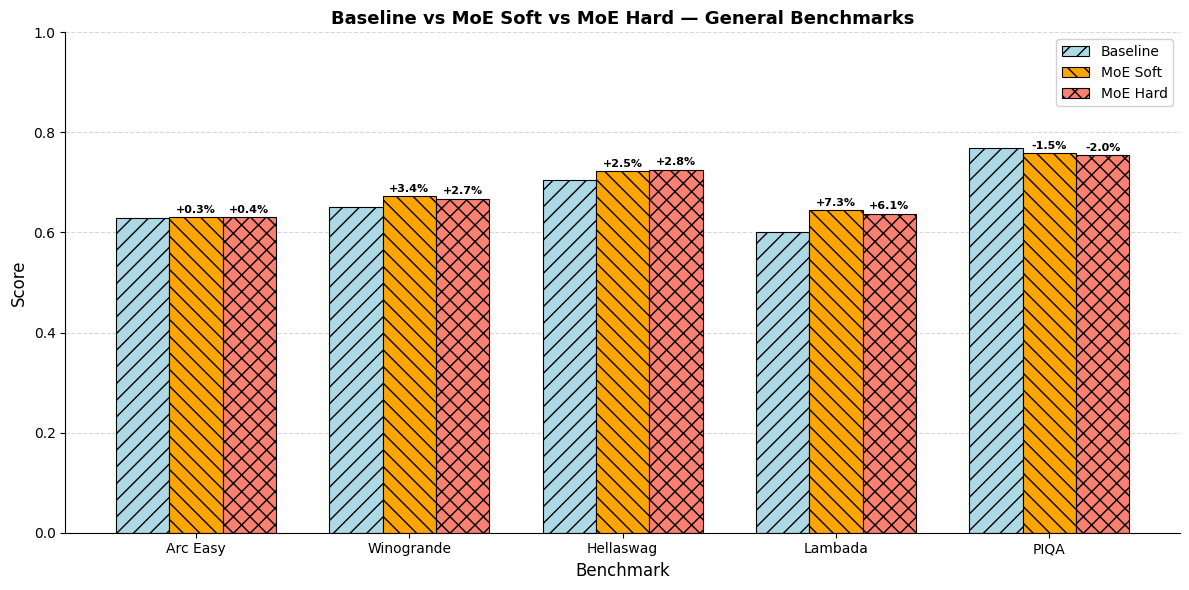

In [35]:
if RUN_FULL_BENCHMARKS:
    x     = np.arange(len(task_labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))

    bars_base = ax.bar(
        x - width, base_scores, width,
        label="Baseline",
        color="lightblue", hatch="//", edgecolor="black", linewidth=0.8
    )
    bars_soft = ax.bar(
        x,          soft_scores, width,
        label="MoE Soft",
        color="orange", hatch="\\\\", edgecolor="black", linewidth=0.8
    )
    bars_hard = ax.bar(
        x + width,  hard_scores, width,
        label="MoE Hard",
        color="salmon", hatch="xx", edgecolor="black", linewidth=0.8
    )

    # Annotate MoE bars with % delta vs baseline
    for bar, base, score in zip(bars_soft, base_scores, soft_scores):
        delta = (score - base) / base * 100 if base else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{delta:+.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold"
        )
    for bar, base, score in zip(bars_hard, base_scores, hard_scores):
        delta = (score - base) / base * 100 if base else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{delta:+.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold"
        )

    ax.set_xlabel("Benchmark",   fontsize=12)
    ax.set_ylabel("Score",       fontsize=12)
    ax.set_title(
        "Baseline vs MoE Soft vs MoE Hard — General Benchmarks",
        fontsize=13, fontweight="bold"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(task_labels)
    ax.set_ylim(0, 1.0)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc="upper right", framealpha=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("Benchmark chart not available (RUN_FULL_BENCHMARKS=False)")